# Modelo NORTE NO2

In [1]:
from utils import logistic_model_station, analyze_logistic_model, recalibrate_threshold, plot_recalibration
import pandas as pd

In [2]:
# load dfs
dfs = {}
names = [
    "SURESTE", "NORESTE", "CENTRO", "NOROESTE", "SUROESTE",
    "NOROESTE 2", "NORTE", "NORESTE2", "SUROESTE2", "SURESTE2",
    "SURESTE 3", "SUR", "NORTE 2", "NORESTE 3", "NOROESTE 3"
]

for name in names:
    dfs[name] = pd.read_csv(f"datos/datosLimpios/estacion_{name.lower()}.csv")


# Filtrar datos por date time, solo datos entre abril 2024 y agosto 2024
# for name, df in dfs.items():
#     df['Date'] = pd.to_datetime(df['Date'])
#     df = df.set_index('Date')
#     # sort
#     df = df.sort_index()
#     df = df.loc['2024-3-01':'2024-3-31']
#     dfs[name] = df.reset_index()


In [3]:
# Ejemplo de uso para la estacion NORTE
model_norte, report_norte = logistic_model_station(
    df=dfs["NORTE"],
    contaminant_idx=3,
    wind_dir_idx=15,
    wind_speed_idx=14,
    rh_idx=10,
    temp_idx=13,
    # backward_selection=True,
)


Umbral crítico: 31.200
Variables utilizadas en el modelo: ['Wind_sin', 'Wind_cos', 'Wind_Speed', 'Humidity', 'Temperature']
Distribución de la variable objetivo: {0: 19084, 1: 2128}


In [4]:
summary_norte = analyze_logistic_model(model_norte, report_norte)



📊 RESUMEN DEL MODELO LOGÍSTICO
                           Logit Regression Results                           
Dep. Variable:               Critical   No. Observations:                14848
Model:                          Logit   Df Residuals:                    14842
Method:                           MLE   Df Model:                            5
Date:                Thu, 11 Sep 2025   Pseudo R-squ.:                  0.1777
Time:                        17:22:45   Log-Likelihood:                -3978.4
converged:                       True   LL-Null:                       -4838.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0608      0.113     -0.537      0.592      -0.283       0.161
Wind_sin       -0.5114      0.057     -8.980      0.000      -0.623      -0.400
Wind_cos        

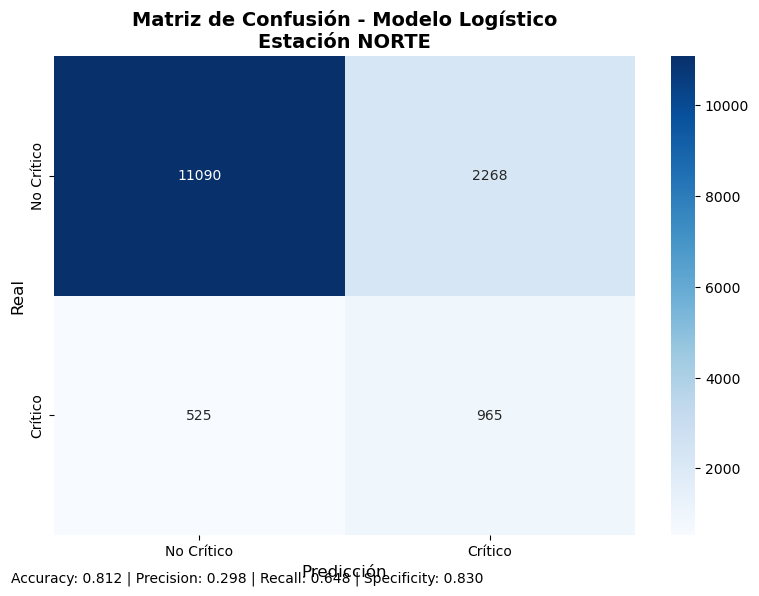

📊 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
Verdaderos Negativos (TN): 11090 - Correctamente clasificados como No Críticos
Falsos Positivos (FP): 2268 - Incorrectamente clasificados como Críticos
Falsos Negativos (FN): 525 - Incorrectamente clasificados como No Críticos
Verdaderos Positivos (TP): 965 - Correctamente clasificados como Críticos

📈 MÉTRICAS:
Accuracy (Exactitud): 0.812
Precision (Precisión): 0.298
Recall (Sensibilidad): 0.648
Specificity (Especificidad): 0.830


In [5]:
# Grafico matriz de confusion
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Obtener datos del modelo
y_test = model_norte.model.endog  # valores reales
X_test = model_norte.model.exog   # características de test

# Probabilidades predichas
y_probs = model_norte.predict(X_test)

# Convertir probabilidades a predicciones binarias (umbral 0.5)
y_pred = (y_probs >= 0.15).astype(int)

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Crítico', 'Crítico'], 
            yticklabels=['No Crítico', 'Crítico'])

plt.title('Matriz de Confusión - Modelo Logístico\nEstación NORTE', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

# Añadir estadísticas adicionales
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

plt.figtext(0.02, 0.02, 
           f'Accuracy: {accuracy:.3f} | Precision: {precision:.3f} | '
           f'Recall: {recall:.3f} | Specificity: {specificity:.3f}',
           fontsize=10, ha='left')

plt.tight_layout()
plt.show()

print("📊 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:")
print("=" * 50)
print(f"Verdaderos Negativos (TN): {tn} - Correctamente clasificados como No Críticos")
print(f"Falsos Positivos (FP): {fp} - Incorrectamente clasificados como Críticos")
print(f"Falsos Negativos (FN): {fn} - Incorrectamente clasificados como No Críticos")
print(f"Verdaderos Positivos (TP): {tp} - Correctamente clasificados como Críticos")
print(f"\n📈 MÉTRICAS:")
print(f"Accuracy (Exactitud): {accuracy:.3f}")
print(f"Precision (Precisión): {precision:.3f}")
print(f"Recall (Sensibilidad): {recall:.3f}")
print(f"Specificity (Especificidad): {specificity:.3f}")

    Threshold  Precision    Recall        F1
0        0.05   0.164348  0.904027  0.278133
1        0.10   0.232760  0.790604  0.359640
2        0.15   0.298484  0.647651  0.408639
3        0.20   0.339044  0.504698  0.405609
4        0.25   0.363694  0.383221  0.373203
5        0.30   0.372803  0.270470  0.313497
6        0.35   0.374819  0.173826  0.237506
7        0.40   0.374723  0.113423  0.174137
8        0.45   0.347015  0.062416  0.105802
9        0.50   0.357576  0.039597  0.071299
10       0.55   0.370000  0.024832  0.046541
11       0.60   0.352941  0.008054  0.015748
12       0.65   0.555556  0.003356  0.006671
13       0.70   1.000000  0.001342  0.002681
14       0.75   0.000000  0.000000  0.000000
15       0.80   0.000000  0.000000  0.000000
16       0.85   0.000000  0.000000  0.000000
17       0.90   0.000000  0.000000  0.000000
18       0.95   0.000000  0.000000  0.000000


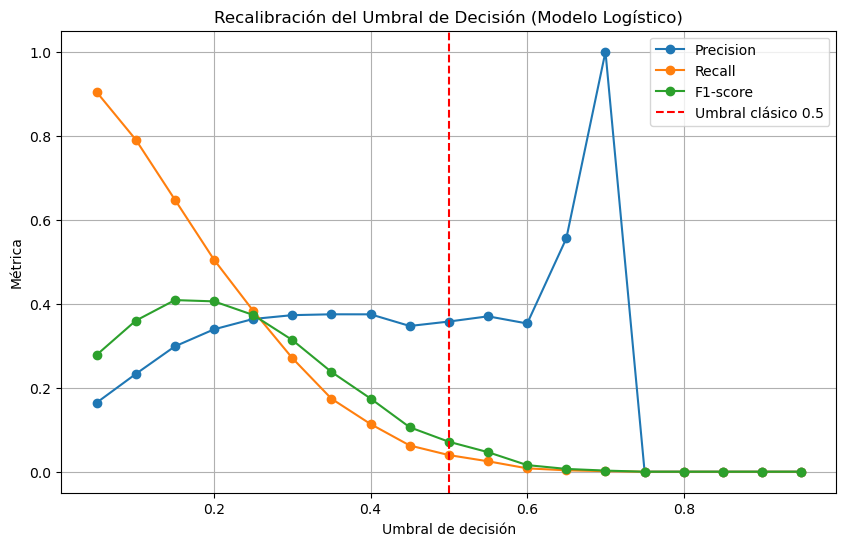

⚡ Mejor umbral encontrado según F1: 0.15


In [6]:
y_test = model_norte.model.endog
X_test = model_norte.model.exog

# Probabilidades predichas correctamente
y_probs_test = model_norte.predict(X_test)

# Barrido de umbrales
results_df = recalibrate_threshold(y_test, y_probs_test, step=0.05)

# Mostrar tabla
print(results_df)

# Graficar
plot_recalibration(results_df)

# Umbral óptimo según F1
best_idx = results_df["F1"].idxmax()
best_threshold = results_df.loc[best_idx, "Threshold"]
print(f"⚡ Mejor umbral encontrado según F1: {best_threshold:.2f}")

# MODELO NORESTE PM2.5

In [7]:
# Ejemplo de uso para la estacion NORTE

model_noreste, report_noreste = logistic_model_station(
    df=dfs["NORESTE"],
    contaminant_idx=7,
    wind_dir_idx=15,
    wind_speed_idx=14,
    rh_idx=10,
    temp_idx=13,
    threshold=33,
    # backward_selection=True,
)


Umbral crítico: 33.000
Variables utilizadas en el modelo: ['Wind_sin', 'Wind_cos', 'Wind_Speed', 'Humidity', 'Temperature']
Distribución de la variable objetivo: {0: 18248, 1: 2964}


In [8]:
summary_norte = analyze_logistic_model(model_noreste, report_noreste)


📊 RESUMEN DEL MODELO LOGÍSTICO
                           Logit Regression Results                           
Dep. Variable:               Critical   No. Observations:                14848
Model:                          Logit   Df Residuals:                    14842
Method:                           MLE   Df Model:                            5
Date:                Thu, 11 Sep 2025   Pseudo R-squ.:                 0.05734
Time:                        17:22:45   Log-Likelihood:                -5661.7
converged:                       True   LL-Null:                       -6006.1
Covariance Type:            nonrobust   LLR p-value:                1.304e-146
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.5549      0.146     -3.794      0.000      -0.842      -0.268
Wind_sin       -0.1688      0.042     -3.983      0.000      -0.252      -0.086
Wind_cos        

    Threshold  Precision    Recall        F1
0        0.05   0.146873  0.964337  0.254921
1        0.10   0.179539  0.817831  0.294439
2        0.15   0.225874  0.626024  0.331970
3        0.20   0.276165  0.440000  0.339342
4        0.25   0.298976  0.225060  0.256805
5        0.30   0.269321  0.055422  0.091926
6        0.35   0.478261  0.005301  0.010486
7        0.40   0.000000  0.000000  0.000000
8        0.45   0.000000  0.000000  0.000000
9        0.50   0.000000  0.000000  0.000000
10       0.55   0.000000  0.000000  0.000000
11       0.60   0.000000  0.000000  0.000000
12       0.65   0.000000  0.000000  0.000000
13       0.70   0.000000  0.000000  0.000000
14       0.75   0.000000  0.000000  0.000000
15       0.80   0.000000  0.000000  0.000000
16       0.85   0.000000  0.000000  0.000000
17       0.90   0.000000  0.000000  0.000000
18       0.95   0.000000  0.000000  0.000000


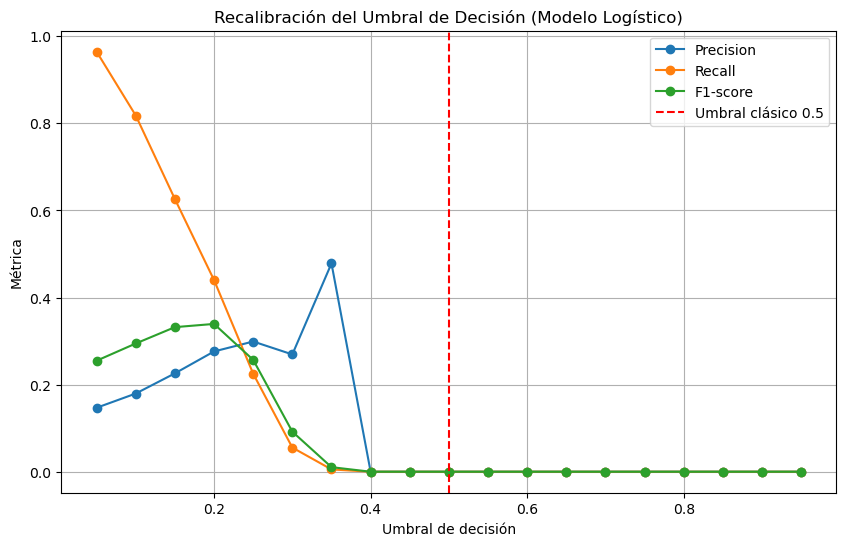

⚡ Mejor umbral encontrado según F1: 0.20


In [9]:
y_test = model_noreste.model.endog
X_test = model_noreste.model.exog

# Probabilidades predichas correctamente
y_probs_test = model_noreste.predict(X_test)

# Barrido de umbrales
results_df2 = recalibrate_threshold(y_test, y_probs_test, step=0.05)

# Mostrar tabla
print(results_df2)

# Graficar
plot_recalibration(results_df2)

# Umbral óptimo según F1
best_idx = results_df2["F1"].idxmax()
best_threshold = results_df2.loc[best_idx, "Threshold"]
print(f"⚡ Mejor umbral encontrado según F1: {best_threshold:.2f}")

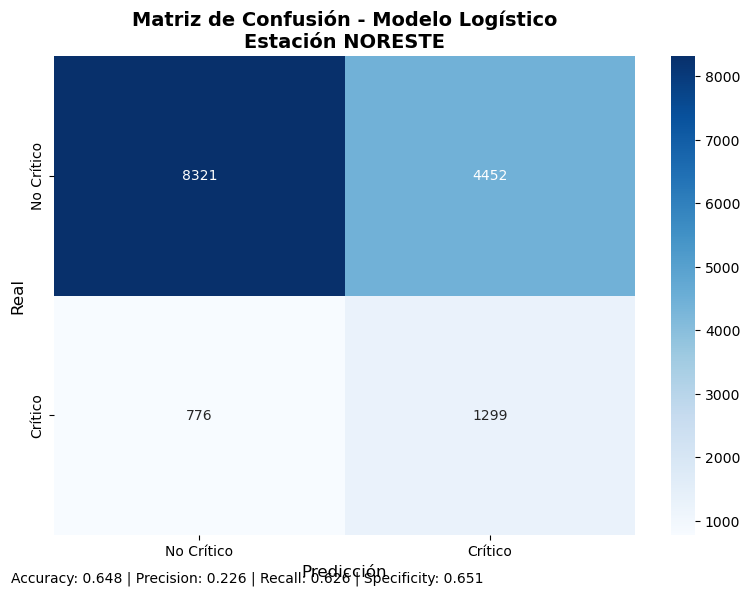

📊 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
Verdaderos Negativos (TN): 8321 - Correctamente clasificados como No Críticos
Falsos Positivos (FP): 4452 - Incorrectamente clasificados como Críticos
Falsos Negativos (FN): 776 - Incorrectamente clasificados como No Críticos
Verdaderos Positivos (TP): 1299 - Correctamente clasificados como Críticos

📈 MÉTRICAS:
Accuracy (Exactitud): 0.648
Precision (Precisión): 0.226
Recall (Sensibilidad): 0.626
Specificity (Especificidad): 0.651


In [10]:
# Grafico matriz de confusion
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Obtener datos del modelo
y_test = model_noreste.model.endog  # valores reales
X_test = model_noreste.model.exog   # características de test

# Probabilidades predichas
y_probs = model_noreste.predict(X_test)

# Convertir probabilidades a predicciones binarias (umbral 0.5)
y_pred = (y_probs >= 0.15).astype(int)

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Crítico', 'Crítico'], 
            yticklabels=['No Crítico', 'Crítico'])

plt.title('Matriz de Confusión - Modelo Logístico\nEstación NORESTE', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

# Añadir estadísticas adicionales
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

plt.figtext(0.02, 0.02, 
           f'Accuracy: {accuracy:.3f} | Precision: {precision:.3f} | '
           f'Recall: {recall:.3f} | Specificity: {specificity:.3f}',
           fontsize=10, ha='left')

plt.tight_layout()
plt.show()

print("📊 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:")
print("=" * 50)
print(f"Verdaderos Negativos (TN): {tn} - Correctamente clasificados como No Críticos")
print(f"Falsos Positivos (FP): {fp} - Incorrectamente clasificados como Críticos")
print(f"Falsos Negativos (FN): {fn} - Incorrectamente clasificados como No Críticos")
print(f"Verdaderos Positivos (TP): {tp} - Correctamente clasificados como Críticos")
print(f"\n📈 MÉTRICAS:")
print(f"Accuracy (Exactitud): {accuracy:.3f}")
print(f"Precision (Precisión): {precision:.3f}")
print(f"Recall (Sensibilidad): {recall:.3f}")
print(f"Specificity (Especificidad): {specificity:.3f}")

In [ ]:
import logistic_model_station

